# XGBoost + RF + SVM Ensemble — Hyperparameter Tuning

In [7]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
import shap
from sklearn.metrics import *
sns.set_palette('Blues');plt.rcParams['axes.prop_cycle']=plt.cycler(color=plt.cm.Blues(np.linspace(0.3,0.9,8)))
import warnings;warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('../datasets/augmented_data.csv')
X=df.drop('diagnosis',axis=1);y=df['diagnosis']
X_tr,X_te,y_tr,y_te=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
sc=StandardScaler();X_tr=sc.fit_transform(X_tr);X_te=sc.transform(X_te)

In [9]:
# Tune XGBoost (most impactful for ensemble)
param_grid={'n_estimators':[50,100,200],'max_depth':[3,5,7]}
gs=GridSearchCV(XGBClassifier(random_state=42,eval_metric='logloss'),param_grid,cv=5,scoring='accuracy')
gs.fit(X_tr,y_tr)
print(f"Best XGB params: {gs.best_params_}, Score: {gs.best_score_:.4f}")
xgb_best=gs.best_estimator_

estimators=[('xgb',xgb_best),('rf',RandomForestClassifier(n_estimators=100,random_state=42)),('svm',SVC(kernel='linear',probability=True,random_state=42))]
m=VotingClassifier(estimators=estimators,voting='soft').fit(X_tr,y_tr)
yp=m.predict(X_te);ypb=m.predict_proba(X_te)[:,1]
print("Tuned Ensemble trained.")

Best XGB params: {'max_depth': 3, 'n_estimators': 200}, Score: 0.9850
Tuned Ensemble trained.


In [10]:
acc=accuracy_score(y_te,yp);prec=precision_score(y_te,yp);rec=recall_score(y_te,yp);f1=f1_score(y_te,yp)
cm=confusion_matrix(y_te,yp);tn,fp,fn,tp=cm.ravel();spec=tn/(tn+fp);auc=roc_auc_score(y_te,ypb)
print(f"Acc:{acc:.4f} Prec:{prec:.4f} Rec:{rec:.4f} F1:{f1:.4f} Spec:{spec:.4f} AUC:{auc:.4f}\nCM:\n{cm}")

Acc:0.9750 Prec:1.0000 Rec:0.9500 F1:0.9744 Spec:1.0000 AUC:0.9971
CM:
[[100   0]
 [  5  95]]


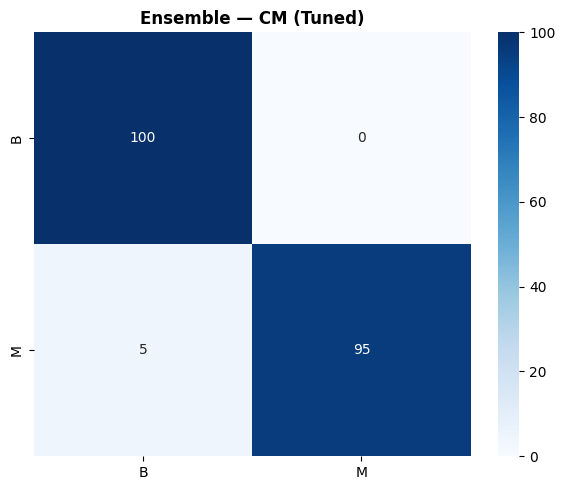

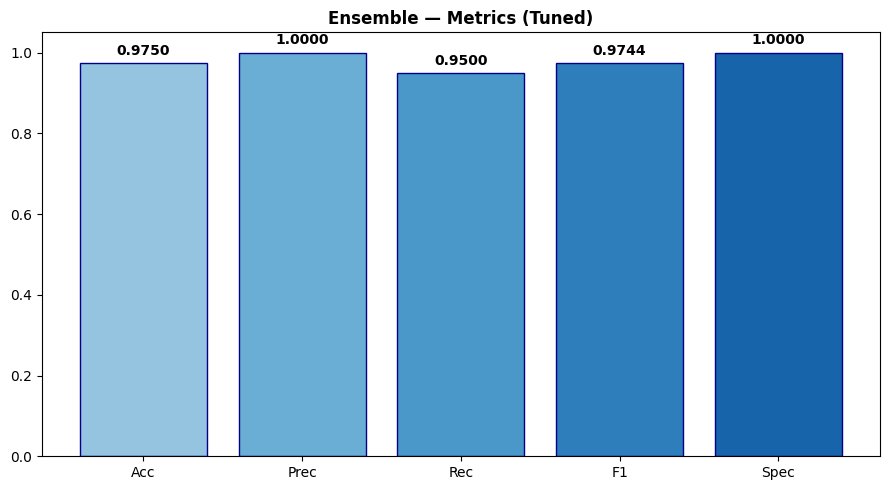

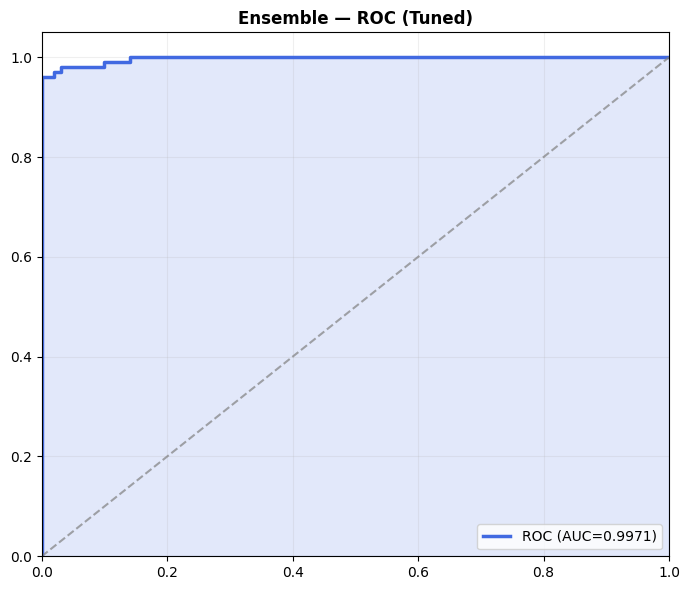

In [11]:
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['B','M'],yticklabels=['B','M'])
plt.title('Ensemble — CM (Tuned)',fontweight='bold');plt.tight_layout();plt.show()
n=['Acc','Prec','Rec','F1','Spec'];v=[acc,prec,rec,f1,spec];c=plt.cm.Blues([0.4,0.5,0.6,0.7,0.8])
plt.figure(figsize=(9,5));bars=plt.bar(n,v,color=c,edgecolor='darkblue')
plt.ylim(0,1.05);plt.title('Ensemble — Metrics (Tuned)',fontweight='bold')
for b,v in zip(bars,v):plt.text(b.get_x()+b.get_width()/2,b.get_height()+0.02,f'{v:.4f}',ha='center',fontweight='bold')
plt.tight_layout();plt.show()
fpr,tpr,_=roc_curve(y_te,ypb)
plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,'royalblue',lw=2.5,label=f'ROC (AUC={auc:.4f})')
plt.fill_between(fpr,tpr,alpha=0.15,color='royalblue')
plt.plot([0,1],[0,1],'gray',ls='--',alpha=0.7)
plt.xlim(0,1);plt.ylim(0,1.05);plt.title('Ensemble — ROC (Tuned)',fontweight='bold')
plt.legend();plt.grid(alpha=0.2);plt.tight_layout();plt.show()

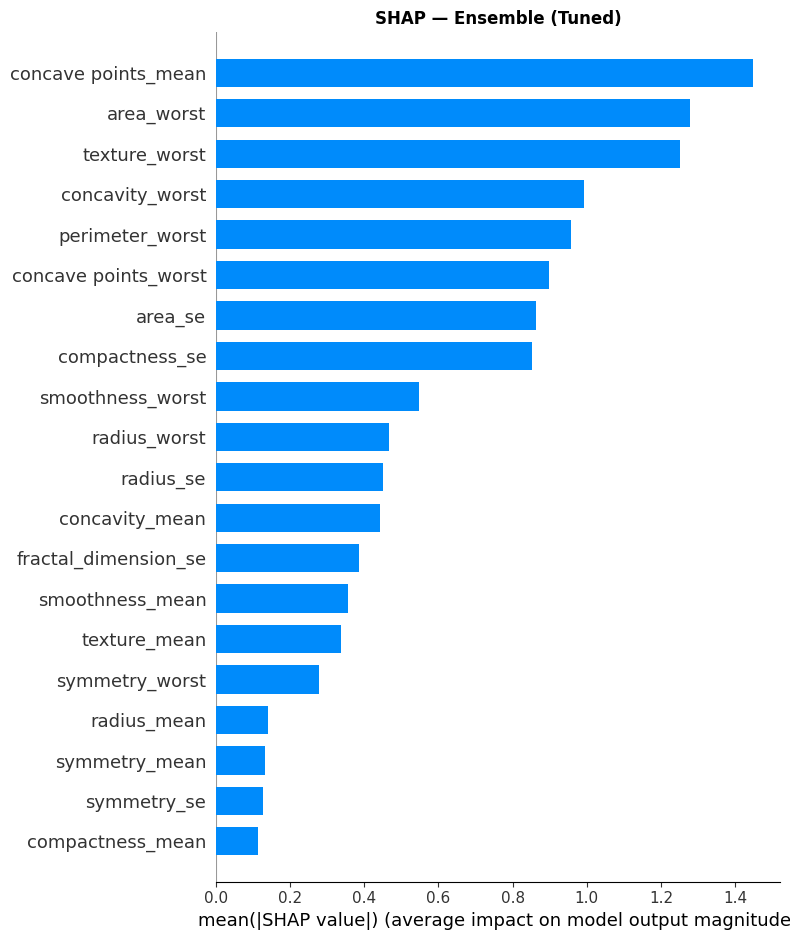

In [12]:
xgb_model=m.named_estimators_['xgb']
explainer=shap.TreeExplainer(xgb_model)
shap_values=explainer.shap_values(X_te)
plt.figure(figsize=(10,6))
shap.summary_plot(shap_values,X_te,feature_names=X.columns,plot_type='bar',show=False)
plt.title('SHAP — Ensemble (Tuned)',fontweight='bold')
plt.tight_layout();plt.show()